# Limpieza, EDA y preprocesamiento del dataset IEEE-CIS Fraud Detection

Este notebook implementa el procedimiento descrito en la sección **3.2** del
informe: análisis exploratorio de datos (EDA) y limpieza del dataset de la
competencia Kaggle *IEEE-CIS Fraud Detection*
(https://www.kaggle.com/c/ieee-fraud-detection).

**Requisito previo:** descargar de Kaggle los archivos
`train_transaction.csv` y `train_identity.csv` y ubicarlos en la misma
carpeta que este notebook (o ajustar la ruta en `DATA_DIR`).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42


##Carga y descripción general del conjunto de datos

In [ ]:
transaction = pd.read_csv("train_transaction.csv")
identity = pd.read_csv("train_identity.csv")

print("train_transaction:", transaction.shape)
print("train_identity   :", identity.shape)
print("Tasa de fraude (isFraud=1):",
      round(transaction['isFraud'].mean() * 100, 2), "%")


train_transaction: (590540, 394)
train_identity   : (144233, 41)
Tasa de fraude (isFraud=1): 3.5 %


## Unión de las tablas de origen

Unión izquierda (*left join*) sobre `TransactionID`, ya que no todas las transacciones tienen identidad asociada.

In [ ]:
df = transaction.merge(identity, on="TransactionID", how="left")
print("Dataset unificado:", df.shape)
del transaction, identity


Dataset unificado: (590540, 434)


## Análisis Exploratorio de Datos (EDA)


### Distribución de la variable objetivo (`isFraud`)

Se examina cuántas transacciones son fraudulentas y cuántas no, para
confirmar el nivel de desbalance de clases mencionado anteriormente.


isFraud
0    569877
1     20663
Name: count, dtype: int64


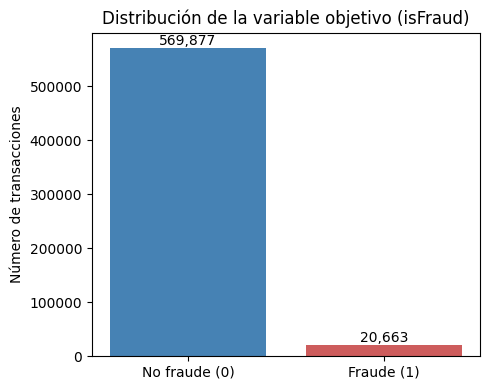

In [ ]:
conteo_clases = df["isFraud"].value_counts()
print(conteo_clases)

plt.figure(figsize=(5, 4))
plt.bar(["No fraude (0)", "Fraude (1)"], conteo_clases.values, color=["steelblue", "indianred"])
plt.ylabel("Número de transacciones")
plt.title("Distribución de la variable objetivo (isFraud)")
for i, v in enumerate(conteo_clases.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


Como se observa, la clase "no fraude" domina ampliamente el dataset
(aproximadamente el 96.5% de los registros), lo que confirma la necesidad de
manejar el desbalance de clases durante el entrenamiento de los modelos
(ver sección 3.2.8).


### Valores faltantes por variable

Se calcula el porcentaje de valores nulos por columna, para tener una
primera idea de qué tan afectado está el dataset antes de decidir qué
columnas eliminar o imputar.


Porcentaje de columnas con más del 50% de valores nulos: 49.3 %


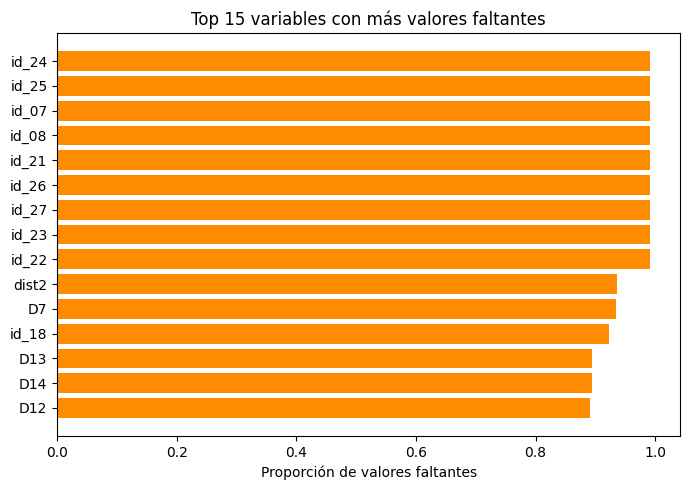

In [ ]:
missing_pct_eda = df.isnull().mean().sort_values(ascending=False)
print("Porcentaje de columnas con más del 50% de valores nulos:",
      round((missing_pct_eda > 0.50).mean() * 100, 1), "%")

top15_missing = missing_pct_eda.head(15)

plt.figure(figsize=(7, 5))
plt.barh(top15_missing.index[::-1], top15_missing.values[::-1], color="darkorange")
plt.xlabel("Proporción de valores faltantes")
plt.title("Top 15 variables con más valores faltantes")
plt.tight_layout()
plt.show()


Se observa que las variables con mayor proporción de nulos corresponden
principalmente a las columnas `id_*` (provenientes de la tabla de identidad,
que no todas las transacciones tienen) y a algunas columnas `D*`. Esto
justifica el criterio de eliminación aplicado más adelante (columnas con más
del 90% de nulos).


### Distribución del monto de transacción (`TransactionAmt`)

Se examina la distribución de los montos antes de aplicar el recorte de
valores atípicos.


count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


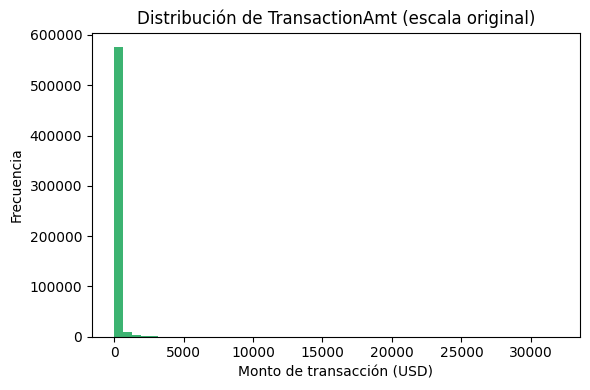

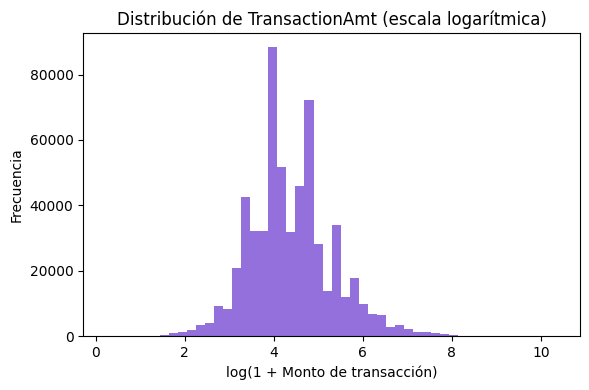

In [ ]:
print(df["TransactionAmt"].describe())

plt.figure(figsize=(6, 4))
plt.hist(df["TransactionAmt"], bins=50, color="mediumseagreen")
plt.xlabel("Monto de transacción (USD)")
plt.ylabel("Frecuencia")
plt.title("Distribución de TransactionAmt (escala original)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(np.log1p(df["TransactionAmt"]), bins=50, color="mediumpurple")
plt.xlabel("log(1 + Monto de transacción)")
plt.ylabel("Frecuencia")
plt.title("Distribución de TransactionAmt (escala logarítmica)")
plt.tight_layout()
plt.show()


La distribución en escala original muestra una fuerte asimetría hacia la
derecha (la mayoría de las transacciones son de montos bajos, con una cola
larga de montos altos). En escala logarítmica la distribución se ve mucho
más cercana a una forma normal, lo que confirma que efectivamente existen
valores atípicos que conviene tratar (sección 3.2.4).


### Monto de transacción según la clase (fraude vs. no fraude)

Se compara la distribución del monto entre transacciones fraudulentas y
legítimas, para ver si existe alguna diferencia visible a simple vista.


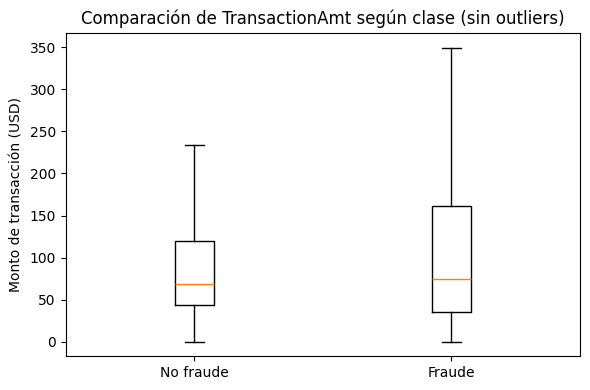

Mediana de monto (no fraude): 68.5
Mediana de monto (fraude)   : 75.0


In [ ]:
monto_no_fraude = df.loc[df["isFraud"] == 0, "TransactionAmt"]
monto_fraude = df.loc[df["isFraud"] == 1, "TransactionAmt"]

plt.figure(figsize=(6, 4))
plt.boxplot(
    [monto_no_fraude, monto_fraude],
    tick_labels=["No fraude", "Fraude"],
    showfliers=False,  # se ocultan valores extremos para poder ver la caja
)
plt.ylabel("Monto de transacción (USD)")
plt.title("Comparación de TransactionAmt según clase (sin outliers)")
plt.tight_layout()
plt.show()

print("Mediana de monto (no fraude):", round(monto_no_fraude.median(), 2))
print("Mediana de monto (fraude)   :", round(monto_fraude.median(), 2))


No se observa una diferencia dramática entre ambas clases en cuanto al
monto de la transacción por sí solo, lo cual sugiere que el monto no es
suficiente para distinguir el fraude y que se necesita el resto de
variables (tipo de producto, tarjeta, dispositivo, etc.) para lograr una
buena clasificación.


### Distribución de la variable `ProductCD`

Se examina cuántas transacciones corresponden a cada tipo de producto, como
ejemplo de exploración de una variable categórica.


ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


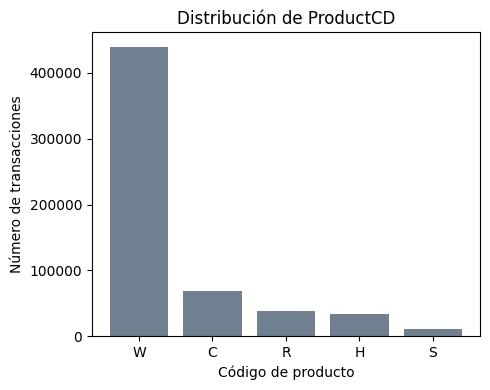

In [ ]:
conteo_producto = df["ProductCD"].value_counts()
print(conteo_producto)

plt.figure(figsize=(5, 4))
plt.bar(conteo_producto.index, conteo_producto.values, color="slategray")
plt.xlabel("Código de producto")
plt.ylabel("Número de transacciones")
plt.title("Distribución de ProductCD")
plt.tight_layout()
plt.show()


Se observa que un producto concentra la mayor parte de las
transacciones, mientras que el resto tiene una representación mucho menor.
Esto es relevante para decidir cómo tratar esta variable en la etapa de
codificación (sección 3.2.5).

Con este panorama general del dataset, se procede a la limpieza propiamente
dicha.


##Tratamiento de valores faltantes

1. Diagnóstico del porcentaje de nulos por columna.
2. Eliminación de columnas con más del 90% de valores faltantes.
3. Imputación de columnas numéricas con la mediana.
4. Imputación de columnas categóricas con la categoría explícita `"missing"`.


In [ ]:
# 1. Diagnóstico de valores faltantes
missing_pct = df.isnull().mean().sort_values(ascending=False)
print(missing_pct.head(15))

# 2. Eliminación de columnas con más del 90% de nulos
UMBRAL_NULOS = 0.90
cols_a_eliminar = missing_pct[missing_pct > UMBRAL_NULOS].index.tolist()
df = df.drop(columns=cols_a_eliminar)
print(f"Columnas eliminadas por exceso de nulos ({UMBRAL_NULOS*100:.0f}%): "
      f"{len(cols_a_eliminar)}")

# Separar tipos de variables restantes (excluyendo identificadores y target)
target_col = "isFraud"
id_cols = ["TransactionID"]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in id_cols + [target_col]]

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Variables numéricas: {len(num_cols)} | Variables categóricas: {len(cat_cols)}")


id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
dtype: float64
Columnas eliminadas por exceso de nulos (90%): 12
Variables numéricas: 391 | Variables categóricas: 29


In [ ]:
# 3. Imputación de variables numéricas con la mediana
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

# 4. Imputación de variables categóricas con la categoría "missing"
for c in cat_cols:
    df[c] = df[c].fillna("missing")

print("Valores nulos restantes:", df.isnull().sum().sum())


Valores nulos restantes: 0


##Tratamiento de valores atípicos en `TransactionAmt`

Recorte (*winsorizing*) de los valores por encima del percentil 99.99,
identificado en el EDA como el punto donde la distribución deja de ser
representativa de la mayoría de las transacciones.


In [ ]:
p9999 = df["TransactionAmt"].quantile(0.9999)
print(f"Percentil 99.99 de TransactionAmt: {p9999:.2f}")

n_antes = df.shape[0]
df = df[df["TransactionAmt"] <= p9999].copy()
print(f"Registros eliminados por outliers en TransactionAmt: {n_antes - df.shape[0]}")


Percentil 99.99 de TransactionAmt: 4222.95
Registros eliminados por outliers en TransactionAmt: 57


##Codificación de variables categóricas

- Variables de **alta cardinalidad** (`DeviceInfo`, `P_emaildomain`,
  `R_emaildomain`): las categorías poco frecuentes se agrupan en `"rare"`
  antes de codificar.
- Variables de **baja cardinalidad** (`ProductCD`, `card4`, `card6`,
  `M1`-`M9`, `DeviceType`, columnas `id_12`-`id_38` restantes): se codifican
  mediante *one-hot encoding*.

**Nota:** se fuerza `dtype=int` en `pd.get_dummies` para que las columnas
resultantes sean tratadas como variables numéricas en los pasos
posteriores (de lo contrario, pandas las crea como tipo `bool`, y quedan
excluidas al filtrar por `select_dtypes(np.number)` más adelante).


In [ ]:
ALTA_CARDINALIDAD_UMBRAL = 20   # nro. de categorías a partir del cual se agrupan las poco frecuentes
FRECUENCIA_MINIMA = 0.01       # categorías con menos de 1% de frecuencia -> "rare"

def agrupar_categorias_poco_frecuentes(serie, frecuencia_minima=FRECUENCIA_MINIMA):
    frecuencias = serie.value_counts(normalize=True)
    categorias_frecuentes = frecuencias[frecuencias >= frecuencia_minima].index
    return serie.where(serie.isin(categorias_frecuentes), other="rare")

cat_cols_actualizadas = [c for c in cat_cols if c in df.columns]

for c in cat_cols_actualizadas:
    n_categorias = df[c].nunique()
    if n_categorias > ALTA_CARDINALIDAD_UMBRAL:
        df[c] = agrupar_categorias_poco_frecuentes(df[c])

print("Cardinalidad tras agrupar categorías poco frecuentes:")
print(df[cat_cols_actualizadas].nunique().sort_values(ascending=False).head(10))


Cardinalidad tras agrupar categorías poco frecuentes:
id_31            10
P_emaildomain     9
R_emaildomain     6
DeviceInfo        6
ProductCD         5
id_34             5
id_33             5
card6             5
card4             5
M4                4
dtype: int64


In [ ]:
df = pd.get_dummies(df, columns=cat_cols_actualizadas, drop_first=True, dtype=int)
print("Dimensiones tras one-hot encoding:", df.shape)


Dimensiones tras one-hot encoding: (590483, 483)


## Tratamiento de la variable temporal `TransactionDT`

`TransactionDT` es un delta de tiempo en segundos respecto de una fecha de
referencia arbitraria, no un timestamp absoluto. Se derivan variables de
hora del día y día de la semana, y luego se descarta la variable original.


In [ ]:
SEGUNDOS_POR_HORA = 3600
SEGUNDOS_POR_DIA = 3600 * 24

df["hora_del_dia"] = (df["TransactionDT"] // SEGUNDOS_POR_HORA) % 24
df["dia_de_la_semana"] = (df["TransactionDT"] // SEGUNDOS_POR_DIA) % 7

# Se conserva TransactionDT únicamente para el split temporal posterior;
# no se usa como variable predictora.


## Reducción de dimensionalidad (PCA sobre columnas `V*`)

Las columnas `V1`-`V339` (features anonimizadas de Vesta) presentan alta
colinealidad entre sí. Se aplica PCA sobre este bloque, conservando los
componentes necesarios para explicar el 95% de la varianza acumulada.


In [ ]:
v_cols = [c for c in df.columns if c.startswith("V") and c[1:].isdigit()]
print(f"Columnas V disponibles tras la limpieza de nulos: {len(v_cols)}")

if len(v_cols) > 0:
    pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
    v_pca = pca.fit_transform(df[v_cols])
    v_pca_cols = [f"V_pca_{i+1}" for i in range(v_pca.shape[1])]
    df_v_pca = pd.DataFrame(v_pca, columns=v_pca_cols, index=df.index)

    df = df.drop(columns=v_cols)
    df = pd.concat([df, df_v_pca], axis=1)

    print(f"Columnas V reducidas de {len(v_cols)} a {v_pca.shape[1]} componentes "
          f"(95% de varianza explicada).")


Columnas V disponibles tras la limpieza de nulos: 339
Columnas V reducidas de 339 a 2 componentes (95% de varianza explicada).


## Balance de clases

Dado el desbalance de clases (~3.5% de fraude, confirmado en el EDA), se
opta por ponderación de clases (`class_weight`) en los clasificadores, en
lugar de técnicas de remuestreo como SMOTE, para no incrementar el costo
computacional del entrenamiento en el contexto de procesamiento
paralelo/distribuido.


In [ ]:
clases = np.unique(df[target_col])
pesos = compute_class_weight(class_weight="balanced", classes=clases, y=df[target_col])
class_weight_dict = dict(zip(clases, pesos))
print("Pesos de clase calculados:", class_weight_dict)

# Estos pesos se pasan luego al parámetro class_weight de los clasificadores,
# por ejemplo: RandomForestClassifier(class_weight=class_weight_dict)


Pesos de clase calculados: {np.int64(0): np.float64(0.5181302549397091), np.int64(1): np.float64(14.289105604491336)}


## Estandarización

Las variables numéricas se transforman a media 0 y desviación estándar 1.
El escalador se ajusta únicamente sobre el conjunto de entrenamiento (ver
sección siguiente) para evitar fuga de información hacia el conjunto de
prueba.


## División del conjunto de datos (split temporal 80/20)

Dado que las transacciones están ordenadas en el tiempo mediante
`TransactionDT`, la división train/test se realiza de forma temporal
(no aleatoria), asignando el 80% de las observaciones más antiguas al
conjunto de entrenamiento y el 20% más reciente al conjunto de prueba.


In [ ]:
df = df.sort_values("TransactionDT").reset_index(drop=True)

corte = int(len(df) * 0.80)
train_df = df.iloc[:corte].copy()
test_df = df.iloc[corte:].copy()

print("Entrenamiento:", train_df.shape)
print("Prueba       :", test_df.shape)

# Variables predictoras (se excluyen identificadores, target y TransactionDT crudo)
cols_excluir = ["TransactionID", "TransactionDT", target_col]
all_numeric_cols_in_df = df.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in all_numeric_cols_in_df if c not in cols_excluir]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

print(f"Número de variables predictoras finales: {len(feature_cols)}")

# Estandarización ajustada solo con el conjunto de entrenamiento
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_cols, index=X_test.index
)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)


Entrenamiento: (472386, 148)
Prueba       : (118097, 148)
Número de variables predictoras finales: 145
X_train_scaled: (472386, 145)
X_test_scaled : (118097, 145)


## Exportación del dataset limpio

Se guardan los conjuntos resultantes para su uso posterior en la etapa de
entrenamiento de los modelos de ensamble (Random Forest, XGBoost, AdaBoost,
KNN) bajo los esquemas de procesamiento paralelo/distribuido.


In [ ]:
OUTPUT_DIR = "./data_limpia"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train_scaled.to_csv(f"{OUTPUT_DIR}/X_train.csv", index=False)
X_test_scaled.to_csv(f"{OUTPUT_DIR}/X_test.csv", index=False)
y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{OUTPUT_DIR}/y_test.csv", index=False)

print("Archivos limpios exportados en:", OUTPUT_DIR)


Archivos limpios exportados en: ./data_limpia
